In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("/kaggle/input/datasets/akashkumardot/titanic/train.csv")

In [3]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [4]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [8]:
df['Age']=df['Age'].fillna(df['Age'].median())

In [9]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
df.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [11]:
df=df.drop(['PassengerId','Name','Cabin'],axis=1)

In [12]:
df.head(20)

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,3,male,22.0,1,0,A/5 21171,7.2500,S
1,1,1,female,38.0,1,0,PC 17599,71.2833,C
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,1,1,female,35.0,1,0,113803,53.1000,S
4,0,3,male,35.0,0,0,373450,8.0500,S
5,0,3,male,28.0,0,0,330877,8.4583,Q
6,0,1,male,54.0,0,0,17463,51.8625,S
7,0,3,male,2.0,3,1,349909,21.0750,S
8,1,3,female,27.0,0,2,347742,11.1333,S
9,1,2,female,14.0,1,0,237736,30.0708,C


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Ticket    891 non-null    object 
 7   Fare      891 non-null    float64
 8   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB


In [ ]:
df['Sex'] = df['Sex'].map({'female': 0, 'male': 1})
data['Embarked_S'] = data['Embarked'].replace('Q',0).replace('C',0).replace('S',1)
data['Embarked_Q'] = data['Embarked'].replace('C',0).replace('S',0).replace('Q',1)
data['Embarked_C'] = data['Embarked'].replace('S',0).replace('Q',0).replace('C',1)

In [14]:
df['Sex'] = df['Sex'].map({'female': 0, 'male': 1})
df = pd.get_dummies(df, columns=['Embarked'],dtype=int)

In [15]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_C,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,A/5 21171,7.2500,0,0,1
1,1,1,0,38.0,1,0,PC 17599,71.2833,1,0,0
2,1,3,0,26.0,0,0,STON/O2. 3101282,7.9250,0,0,1
3,1,1,0,35.0,1,0,113803,53.1000,0,0,1
4,0,3,1,35.0,0,0,373450,8.0500,0,0,1


In [16]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_C,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,A/5 21171,7.2500,0,0,1
1,1,1,0,38.0,1,0,PC 17599,71.2833,1,0,0
2,1,3,0,26.0,0,0,STON/O2. 3101282,7.9250,0,0,1
3,1,1,0,35.0,1,0,113803,53.1000,0,0,1
4,0,3,1,35.0,0,0,373450,8.0500,0,0,1


In [17]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Ticket        0
Fare          0
Embarked_C    0
Embarked_Q    0
Embarked_S    0
dtype: int64

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
sns.set_theme()

In [20]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_C,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,A/5 21171,7.2500,0,0,1
1,1,1,0,38.0,1,0,PC 17599,71.2833,1,0,0
2,1,3,0,26.0,0,0,STON/O2. 3101282,7.9250,0,0,1
3,1,1,0,35.0,1,0,113803,53.1000,0,0,1
4,0,3,1,35.0,0,0,373450,8.0500,0,0,1


<Axes: xlabel='Age', ylabel='Count'>

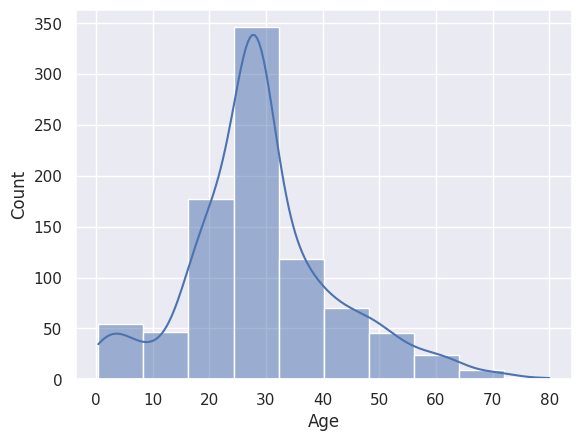

In [24]:
sns.histplot(df['Age'],bins=10,kde=True)

<Axes: xlabel='Sex', ylabel='count'>

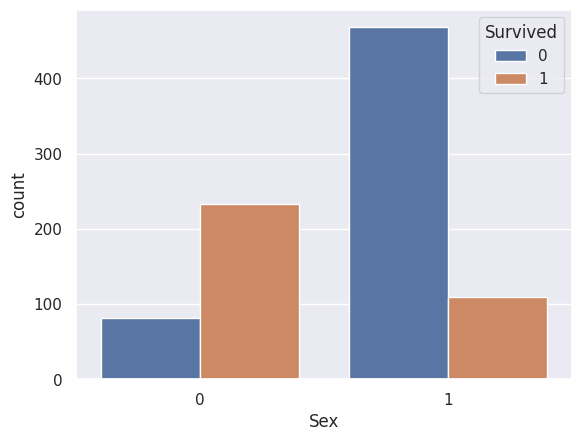

In [27]:
sns.countplot(x='Sex',data=df,hue='Survived')

<Axes: xlabel='Age', ylabel='Count'>

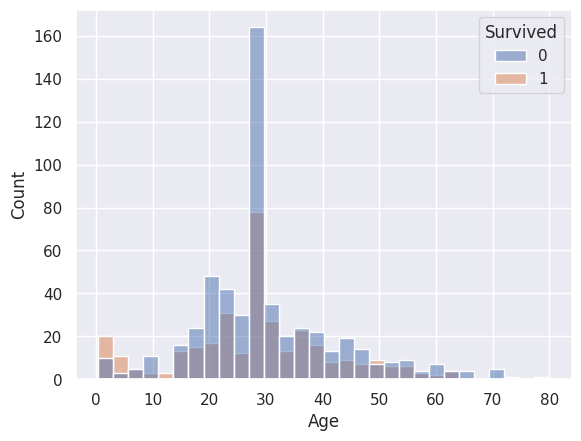

In [32]:
sns.histplot(x='Age',data=df,hue='Survived')

<Axes: xlabel='Pclass', ylabel='count'>

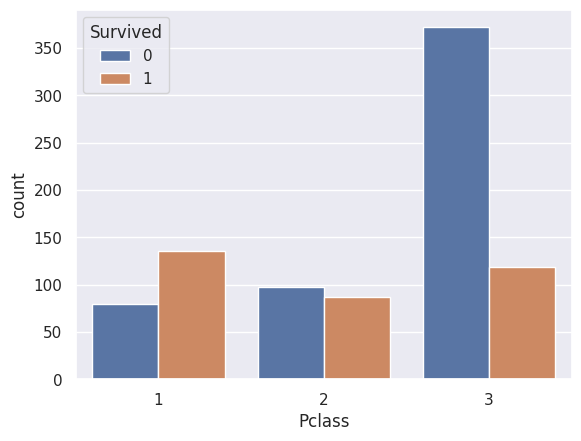

In [37]:
sns.countplot(x='Pclass',hue='Survived',data=df)

In [38]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_C,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,A/5 21171,7.2500,0,0,1
1,1,1,0,38.0,1,0,PC 17599,71.2833,1,0,0
2,1,3,0,26.0,0,0,STON/O2. 3101282,7.9250,0,0,1
3,1,1,0,35.0,1,0,113803,53.1000,0,0,1
4,0,3,1,35.0,0,0,373450,8.0500,0,0,1


In [40]:
df.drop(['Ticket'],inplace=True,axis=1)

In [41]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,0,0,1
1,1,1,0,38.0,1,0,71.2833,1,0,0
2,1,3,0,26.0,0,0,7.9250,0,0,1
3,1,1,0,35.0,1,0,53.1000,0,0,1
4,0,3,1,35.0,0,0,8.0500,0,0,1


In [67]:
y=df['Survived']
x=df.drop(['Survived'],axis=1)

In [68]:
x.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,3,1,22.0,1,0,7.2500,0,0,1
1,1,0,38.0,1,0,71.2833,1,0,0
2,3,0,26.0,0,0,7.9250,0,0,1
3,1,0,35.0,1,0,53.1000,0,0,1
4,3,1,35.0,0,0,8.0500,0,0,1


In [69]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [70]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.34)  

In [71]:
x_train.shape

(588, 9)

In [72]:
x_test.shape

(303, 9)

In [73]:
y_train.shape

(588,)

In [74]:
y_test.shape

(303,)

In [75]:
from sklearn.ensemble import RandomForestClassifier

In [77]:
from sklearn.metrics import accuracy_score

In [78]:
clf = RandomForestClassifier(n_estimators=100)
clf.fit(x_train, y_train)

RandomForestClassifier()

In [79]:
train_predict=clf.predict(x_train)
train_accur=accuracy_score(train_predict,y_train)
print(train_accur)

0.9863945578231292


In [80]:
test_predict=clf.predict(x_test)
test_accur=accuracy_score(test_predict,y_test)
print(test_accur)

0.8118811881188119


In [81]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [84]:
cm = confusion_matrix(y_test, test_predict)
print(cm)

[[166  25]
 [ 32  80]]


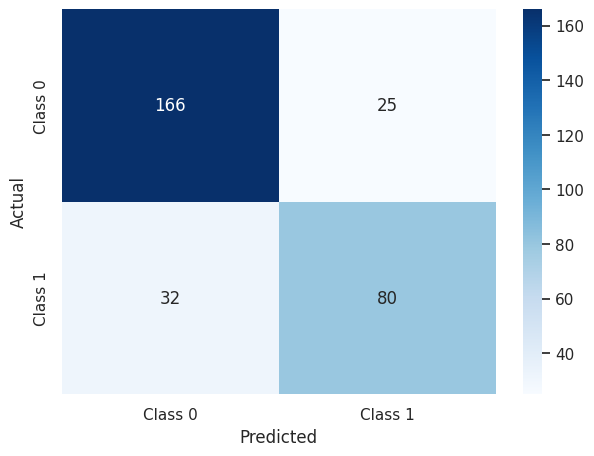

In [85]:
import pandas as pd
display_labels = ["Class 0", "Class 1"] 
df_cm = pd.DataFrame(cm, index=display_labels, columns=display_labels)
plt.figure(figsize=(7, 5))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [86]:
cm1 = confusion_matrix(y_train, train_predict)
print(cm1)

[[353   5]
 [  3 227]]


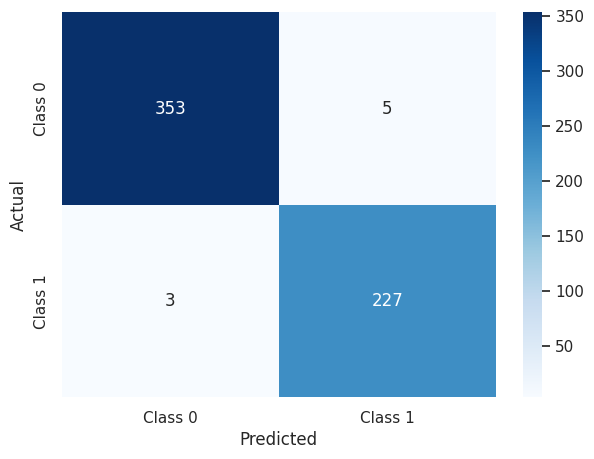

In [87]:
display_labels = ["Class 0", "Class 1"] 
df_cm = pd.DataFrame(cm1, index=display_labels, columns=display_labels)
plt.figure(figsize=(7, 5))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()